# Assignment 2. Option 2

## Dataset Exploration

In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
!bash ./src/download_voxconverse.sh

Annotations already present, skipping clone.
Audio already present, skipping download.


## Pyannote-Based System

## Custom Implementation (PyTorch / Torchaudio / PyTorch-Lightning)

In [21]:
from pathlib import Path
from src.dataset import VoxConverseDataset, AudioSampler, make_collate_fn
from src.models import MelSpectrogramExtractor, VoiceActivityDetector
from src.train import train_vad, plot_history
from torch.utils.data import DataLoader
import soundfile as sf
import torch
import matplotlib.pyplot as plt

DATA_DIR = Path("data")
AUDIO_DIR = DATA_DIR / "audio"
ANNOTATIONS_DIR = DATA_DIR / "annotations"
IMG_DIR = Path("img")
MODELS_DIR = Path("models")
DIR_DEV = "dev"
DIR_TEST = "test"
SAMPLE_RATE = 16_000
HOP = 10
VAD_MODEL = MODELS_DIR / "vad.pt"

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [22]:
dataset_dev = VoxConverseDataset(
  annotations_dir=ANNOTATIONS_DIR / DIR_DEV,
  audio_dir=AUDIO_DIR / DIR_DEV,
  sample_rate=SAMPLE_RATE,
)

dataset_test = VoxConverseDataset(
  annotations_dir=ANNOTATIONS_DIR / DIR_TEST,
  audio_dir=AUDIO_DIR / DIR_TEST,
  sample_rate=SAMPLE_RATE,
)

dev_lengths  = [sf.info(p).frames for p in dataset_dev.audio_files]
test_lengths = [sf.info(p).frames for p in dataset_test.audio_files]

dataloader_dev = DataLoader(
  dataset_dev,
  batch_sampler=AudioSampler(dev_lengths, batch_size=8, shuffle=True),
  collate_fn=make_collate_fn(HOP, SAMPLE_RATE),
)

dataloader_test = DataLoader(
  dataset_test,
  batch_sampler=AudioSampler(dev_lengths, batch_size=8, shuffle=False),
  collate_fn=make_collate_fn(HOP, SAMPLE_RATE),
)

### A Voice Activity Detection (VAD) model using a supervised neural network approach

<div align="center"><img src="img/vad.png" height="800"></div>

In [ ]:
VAD_RETRAIN=False

vad = VoiceActivityDetector(
  device=device,
  spectrogram_layer=MelSpectrogramExtractor(
    sample_rate=SAMPLE_RATE,
    hop_ms=HOP,
  )
)

if VAD_MODEL.exists() and not VAD_RETRAIN:
  vad.load_state_dict(torch.load(VAD_MODEL, weights_only=True))
  print(f"VAD loaded from {VAD_MODEL}")
else:
  epochs = 7
  lr = 1e-3

  print(f"Device: {device}")

  history = train_vad(vad, device, lr, epochs, dataloader_dev, dataloader_test)
  fig = plot_history(history)
  fig.savefig(IMG_DIR / "vad_metrics.png", dpi=150, bbox_inches="tight")
  fig.show()

  torch.save(vad.state_dict(), MODELS_DIR / "vad.pt")

VAD loaded from models/vad.pt


23842 -> 746   ratio: 31.959785522788202


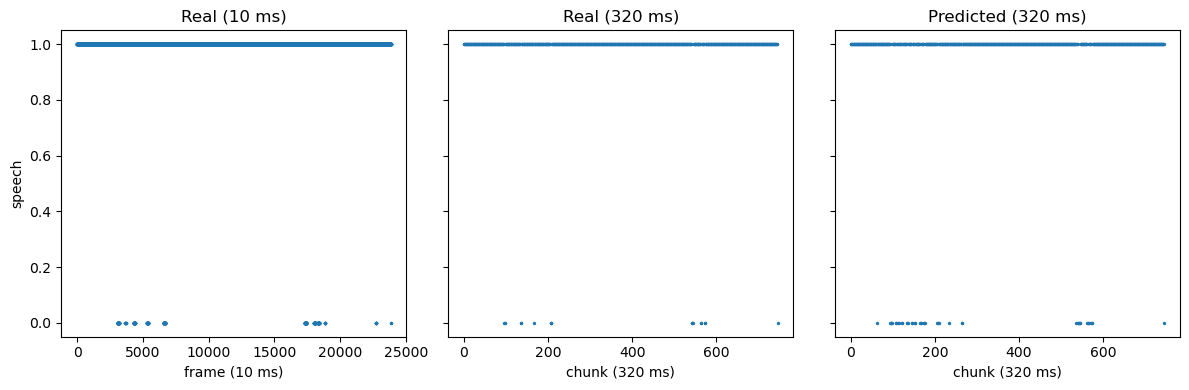

In [58]:
(waveform, labels, mask) = next(iter(dataloader_dev))

m10 = mask[0]
y10 = labels[0][m10].numpy()

with torch.no_grad():
    vad.eval()
    x = tuple(t for t in (waveform, labels, mask))
    pred, labels_c, mask_c = vad(x)          # each is (B, n_chunks)

    m0     = mask_c[0]                        # clip 0's valid chunks
    truth0 = labels_c[0][m0].cpu().numpy()    # clip 0 @ 320 ms, truth
    pred0  = (torch.sigmoid(pred[0]) > 0.5)[m0].cpu().numpy()   # clip 0 @ 320 ms, pred

print(len(y10), "->", len(truth0), "  ratio:", len(y10) / len(truth0))  # expect ~32

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

ax1.scatter(range(len(y10)), y10, s=2)
ax1.set(title="Real (10 ms)", xlabel="frame (10 ms)", ylabel="speech")

ax2.scatter(range(len(truth0)), truth0, s=2)
ax2.set(title="Real (320 ms)", xlabel="chunk (320 ms)")

ax3.scatter(range(len(pred0)), pred0, s=2)
ax3.set(title="Predicted (320 ms)", xlabel="chunk (320 ms)")

fig.tight_layout()


### A segmentation model utilizing permutation invariant CE loss.